RUL cap = 150

CONFIG = {

    'WINDOW_SIZE': 60,
    'STRIDE': 2,
    'LSTM_UNITS': [128, 64],
    'DENSE_UNITS': 80,
    'DROPOUT_RATE': 0.3,
    'L2_REG': 0.001,
    'BATCH_SIZE': 32,
    'EPOCHS': 200,
    'LEARNING_RATE': 0.0005,
    'PATIENCE': 35,
    'N_SPLITS': 5
}

=== Cross-Validation Summary ===

MAE: 14.8380,

RMSE: 20.5043,

R²: 0.8056

Best Fold: 4


✅ Weighted Ensemble Test Results:

  MAE:  13.8197

  RMSE: 21.0260
  
  R²:   0.8346

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Pre-processing

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [ ]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio)",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/train_FD002.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/test_FD002.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/RUL_FD002.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

In [ ]:

# corr = df_train.corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))

# f, ax = plt.subplots(figsize=(20, 20))
# cmap = sns.diverging_palette(230, 10, as_cmap=True)

# # Draw the heatmap with annotation
# sns.heatmap(
#     corr,
#     mask=mask,
#     cmap=cmap,
#     vmax=.3,
#     center=0,
#     square=True,
#     linewidths=.5,
#     cbar_kws={"shrink": .5},
#     annot=True,           # <- Add this line
#     fmt=".1f"             # <- Format the numbers to 2 decimal places
# )

# plt.show()


In [ ]:
# sens_const_values = []
# for feature in list(setting_names + sensor_names):
#     try:
#         if df_train[feature].min()==df_train[feature].max():
#             sens_const_values.append(feature)
#     except:
#         pass

# print(sens_const_values)
# df_train.drop(sens_const_values,axis=1,inplace=True)
# df_test.drop(sens_const_values,axis=1,inplace=True)

In [ ]:
# cor_matrix = df_train.corr().abs()
# upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
# corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
# print(corr_features)
# df_train.drop(corr_features,axis=1,inplace=True)
# df_test.drop(corr_features,axis=1,inplace=True)

In [ ]:
features = list(df_train.columns)

In [ ]:
# # check for missing data
# for feature in features:
#     print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

In [ ]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,149
2,269
3,206
4,235
5,154


In [ ]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [ ]:
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

# the RUL prediction is only useful nearer to the end of the engine's life, therefore we put an upper limit on the RUL
# this is a bit sneaky, since it supposes that the test set has RULs of less than this value, the closer you are
# to the true value, the more accurate the model will be

In [ ]:
df_train['RUL'][df_train['RUL']>150]=150
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(Engine pressure ratio(P50/P2),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,8.00,194.64,2222.65,8341.91,1.02,42.02,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,148
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,5.71,138.51,2211.57,8303.96,1.02,42.20,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,147
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,9.02,175.71,1915.11,8001.42,0.94,36.69,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,146
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,5.71,138.46,2211.58,8303.96,1.02,41.96,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,145
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,9.03,175.05,1915.10,7993.23,0.94,36.89,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,144


In [ ]:
def create_sequences(df, window_size, stride, engine_col='engine'):
    sequences, targets, engine_ids = [], [], []

    for engine_id in df[engine_col].unique():
        engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
        feature_cols = [col for col in engine_data.columns if col not in ['engine', 'cycle', 'RUL']]

        values = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values

        for i in range(0, len(values) - window_size + 1, stride):
            sequences.append(values[i:i + window_size])
            targets.append(rul_values[i + window_size - 1])
            engine_ids.append(engine_id)

    return np.array(sequences), np.array(targets), np.array(engine_ids)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_cols = [col for col in df_train.columns if col not in ['engine', 'cycle', 'RUL']]
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

In [ ]:
pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


Optimized Configuration:
  WINDOW_SIZE: 60
  STRIDE: 2
  LSTM_UNITS: [128, 64]
  DENSE_UNITS: 80
  DROPOUT_RATE: 0.3
  L2_REG: 0.001
  BATCH_SIZE: 32
  EPOCHS: 200
  LEARNING_RATE: 0.0005
  PATIENCE: 35
  N_SPLITS: 5
Training sequences: (19277, 60, 24)
Test sequences: (9702, 60, 24)

========================= FOLD 1/5 =========================
Epoch 1/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 48.6995 - mae: 48.3525 - mse: 3651.2073

482/482 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - loss: 48.6753 - mae: 48.3284 - mse: 3648.2205 - val_loss: 24.4852 - val_mae: 24.2622 - val_mse: 900.6775 - learning_rate: 5.0000e-04
Epoch 2/200
481/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 22.2074 - mae: 21.9921 - mse: 819.9492

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 22.2044 - mae: 21.9892 - mse: 819.7833 - val_loss: 20.5311 - val_mae: 20.3370 - val_mse: 709.5952 - learning_rate: 5.0000e-04
Epoch 3/200
481/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 19.1621 - mae: 18.9728 - mse: 636.6965

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 19.1609 - mae: 18.9716 - mse: 636.6469 - val_loss: 18.9955 - val_mae: 18.8217 - val_mse: 635.2637 - learning_rate: 5.0000e-04
Epoch 4/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 17.4050 - mae: 17.2341 - mse: 541.0404

482/482 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 17.4040 - mae: 17.2332 - mse: 540.9895 - val_loss: 16.9667 - val_mae: 16.8068 - val_mse: 515.1576 - learning_rate: 5.0000e-04
Epoch 5/200
481/482 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 16.1854 - mae: 16.0287 - mse: 476.3668

...

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 23.4394 - mae: 23.2561 - mse: 909.0776 - val_loss: 18.0601 - val_mae: 17.8852 - val_mse: 565.6095 - learning_rate: 5.0000e-04
Epoch 3/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 18.7210 - mae: 18.5494 - mse: 617.4678

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 18.7199 - mae: 18.5483 - mse: 617.4169 - val_loss: 15.7420 - val_mae: 15.5756 - val_mse: 444.2331 - learning_rate: 5.0000e-04
Epoch 4/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 17.0309 - mae: 16.8692 - mse: 524.5415

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 17.0300 - mae: 16.8684 - mse: 524.5034 - val_loss: 15.6772 - val_mae: 15.5257 - val_mse: 448.1815 - learning_rate: 5.0000e-04
Epoch 5/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 16.0850 - mae: 15.9351 - mse: 470.8927

482/482 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 16.0841 - mae: 15.9342 - mse: 470.8518 - val_loss: 15.4436 - val_mae: 15.2987 - val_mse: 426.6729 - learning_rate: 5.0000e-04
Epoch 6/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 14.8324 - mae: 14.6890 - mse: 409.7648

482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 14.8320 - mae: 14.6886 - mse: 409.7478 - val_loss: 14.6222 - val_mae: 14.4836 - val_mse: 398.3489 - learning_rate: 5.0000e-04
Epoch 7/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 13.7861 - mae: 13.6489 - mse: 353.1209 - val_loss: 15.3242 - val_mae: 15.1886 - val_mse: 437.8206 - learning_rate: 5.0000e-04
Epoch 8/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 13.0915 - mae: 12.9564 - mse: 324.0965 - val_loss: 16.5032 - val_mae: 16.3699 - val_mse: 511.5040 - learning_rate: 5.0000e-04
Epoch 9/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 12.4053 - mae: 12.2697 - mse: 287.8855 - val_loss: 18.9548 - val_mae: 18.8225 - val_mse: 661.0865 - learning_rate: 5.0000e-04
Epoch 10/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 11.7275 - mae: 11.5902 - mse: 255.2879 - val_loss: 16.3406 - val_mae: 16.2053 - val_mse: 514.0875 - learning_rate: 5.0000e-04
Epoch 11/200
482/482 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 10

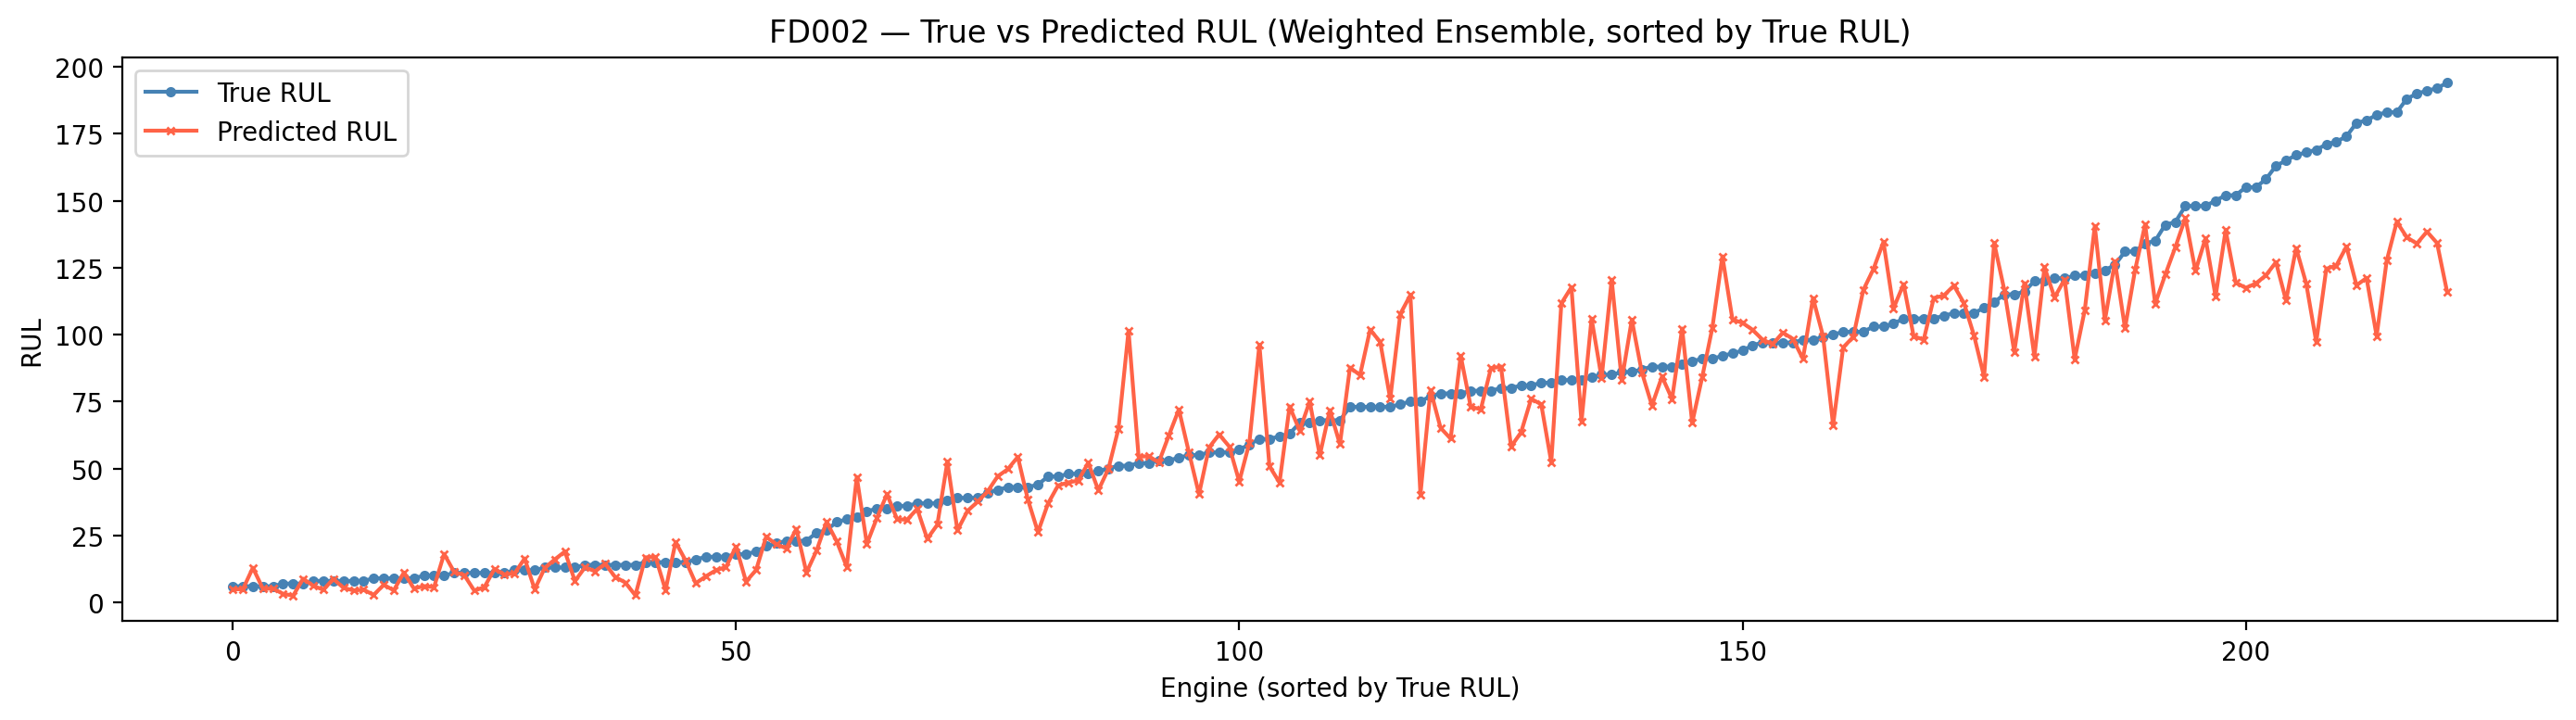

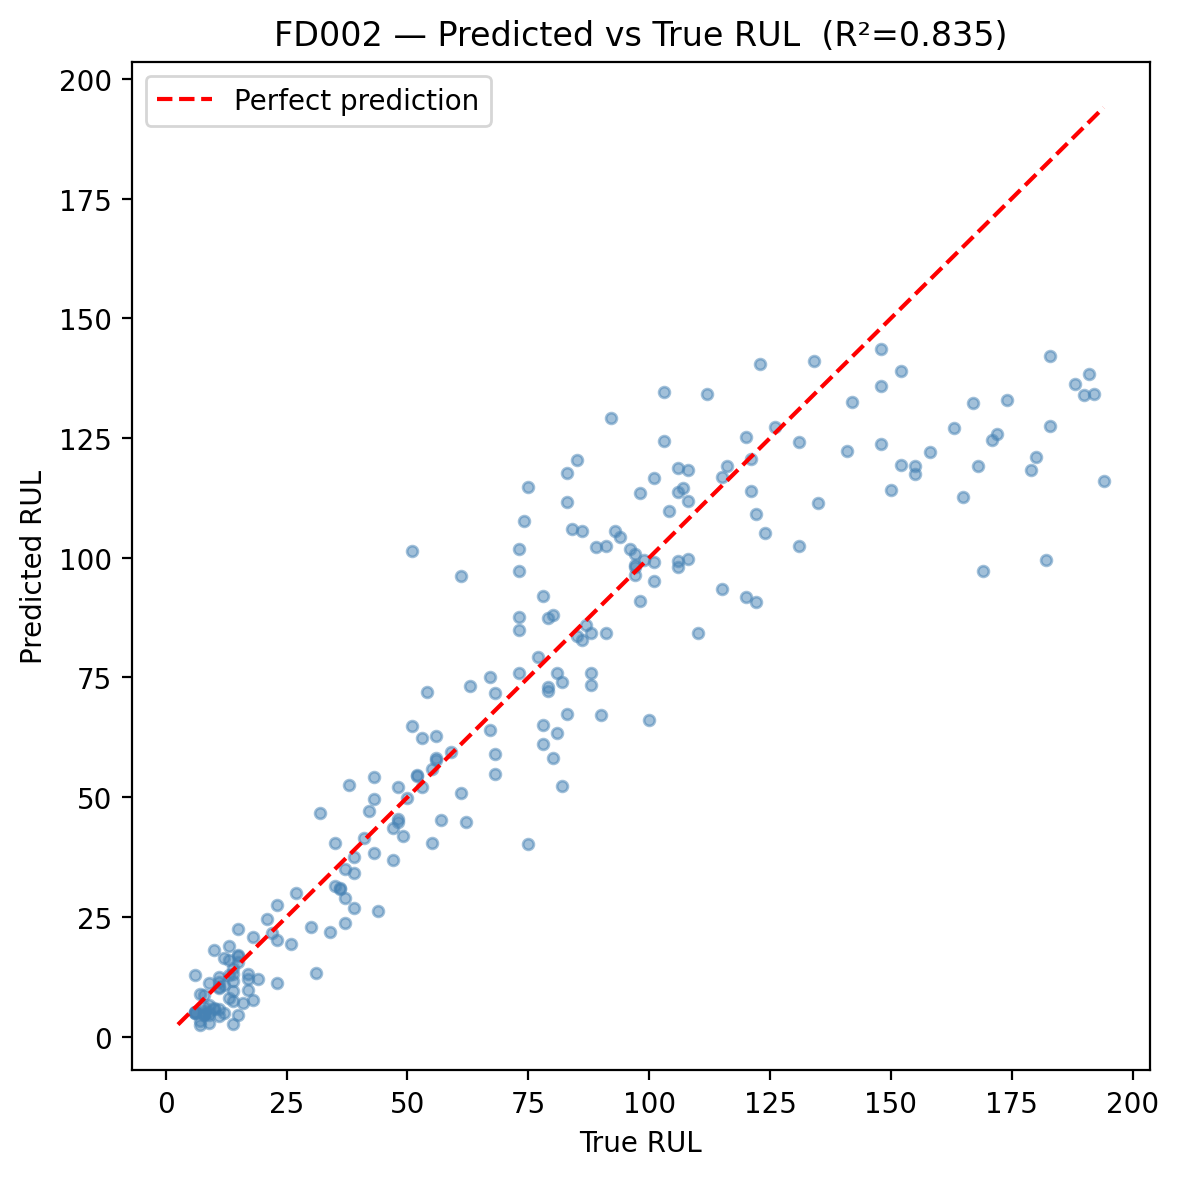

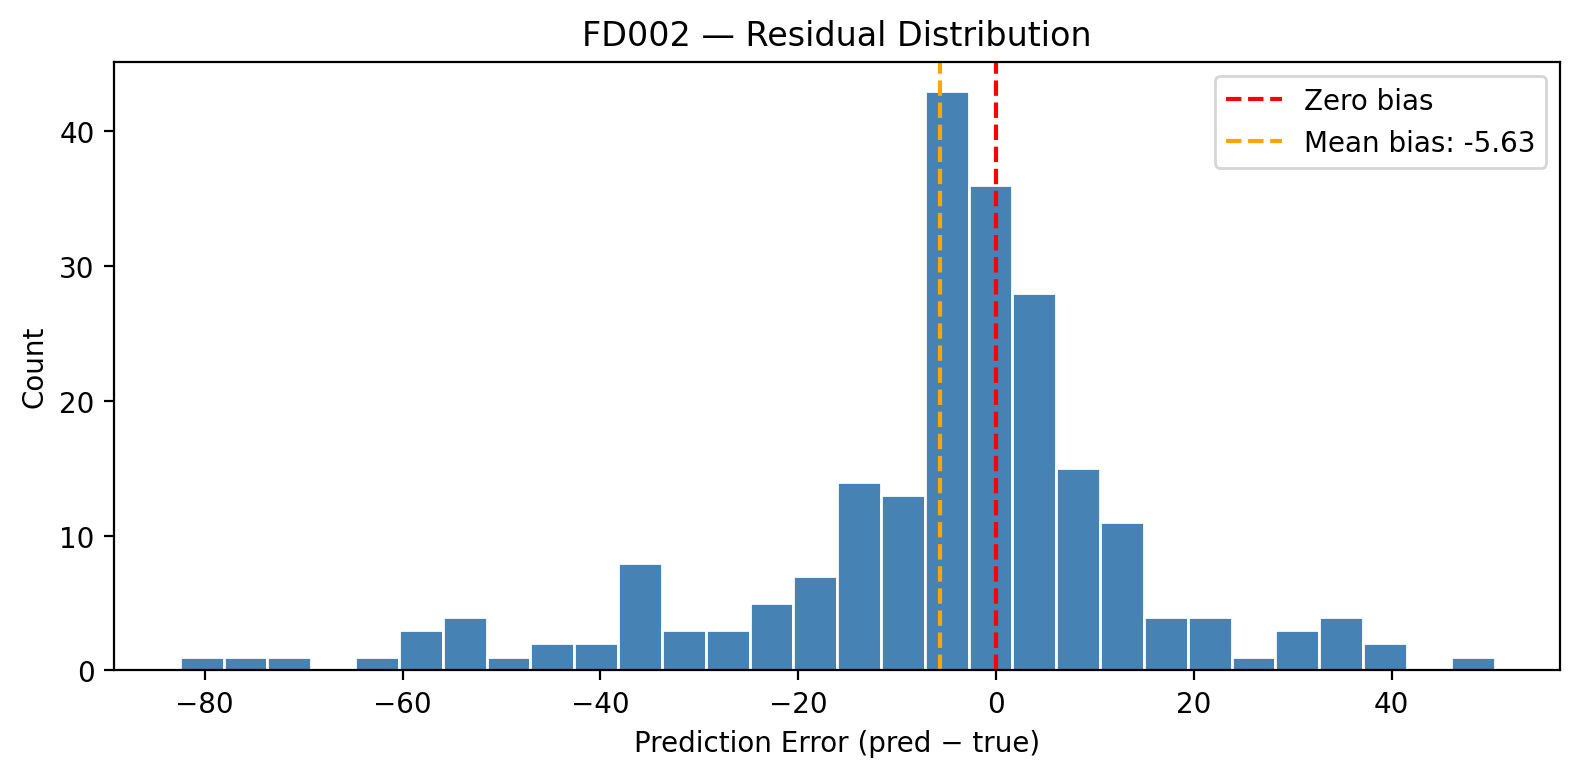

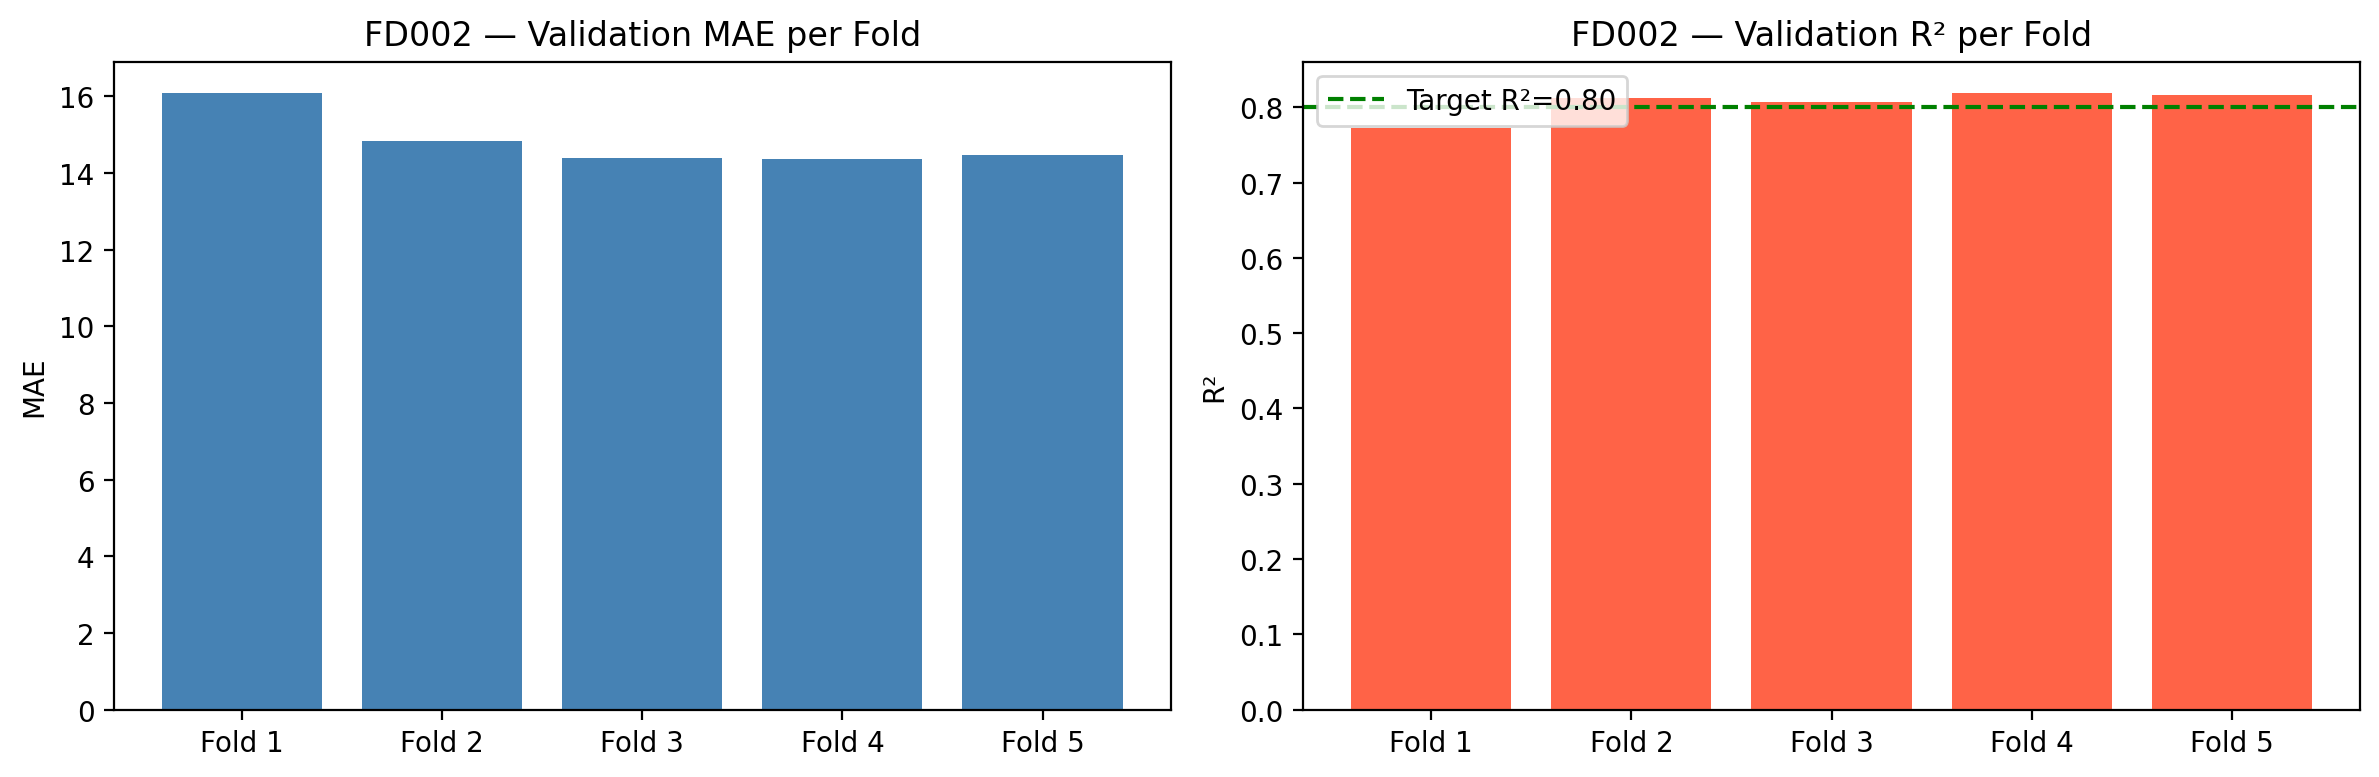

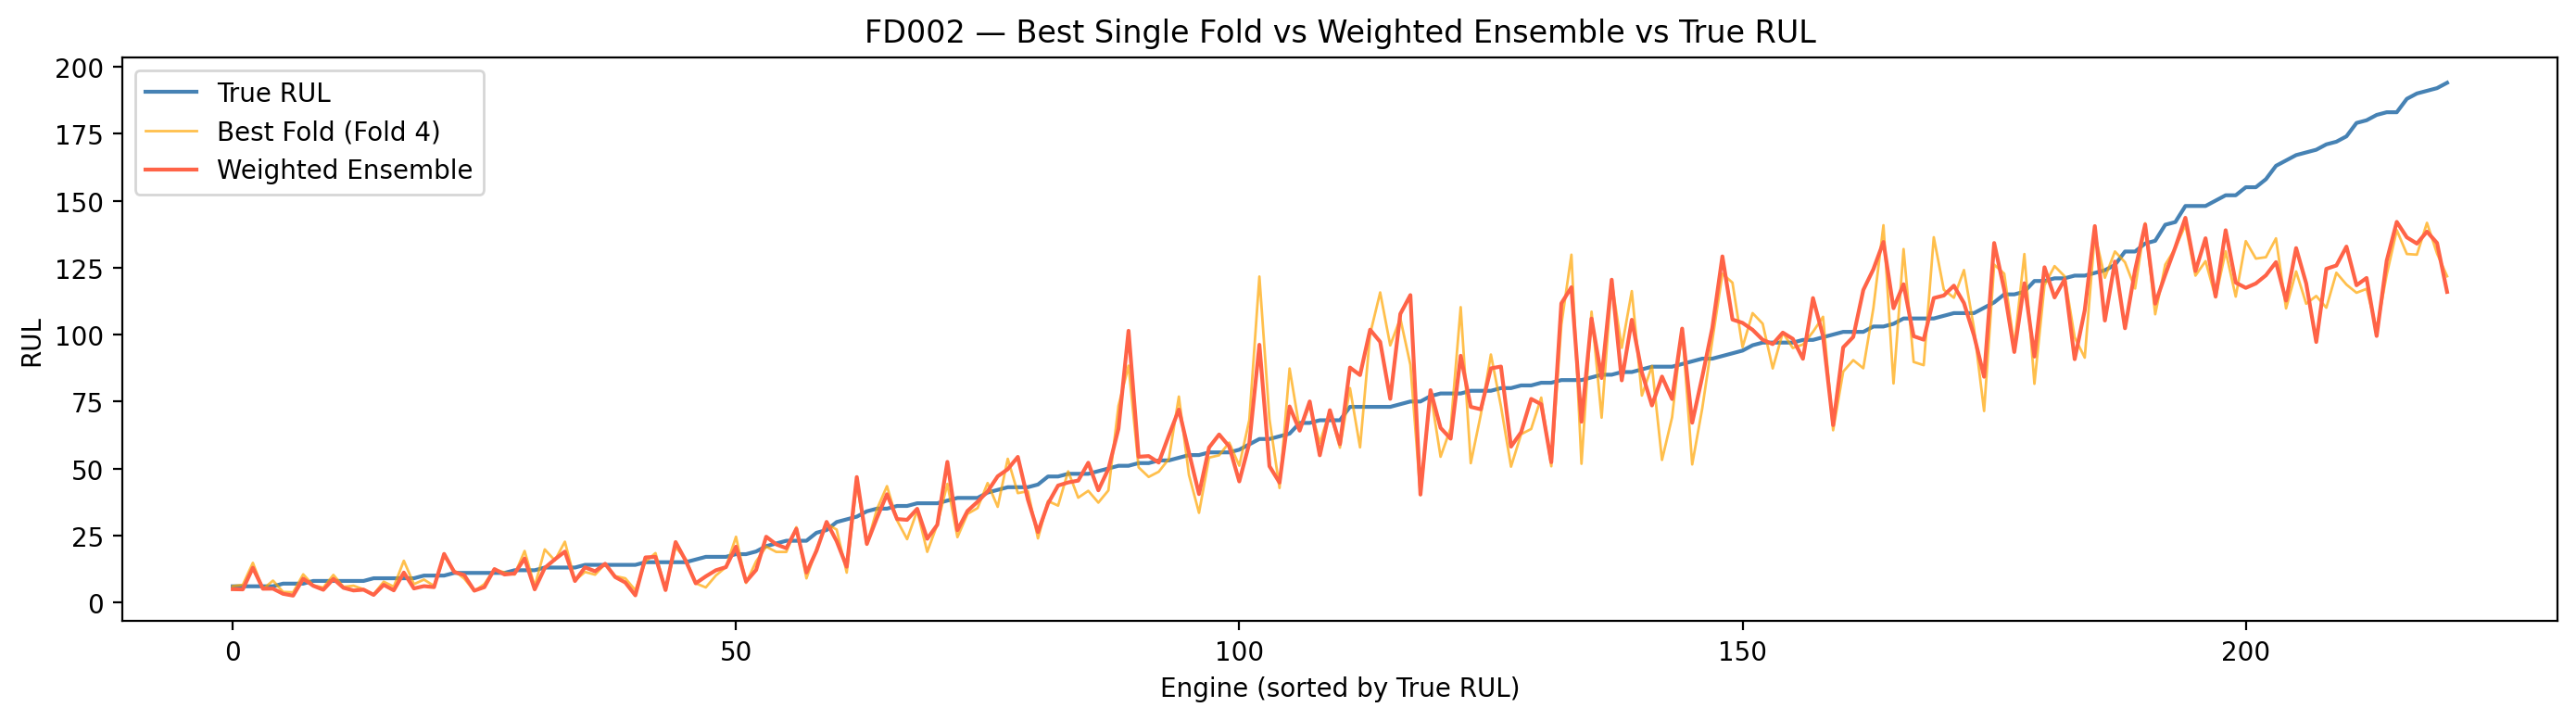

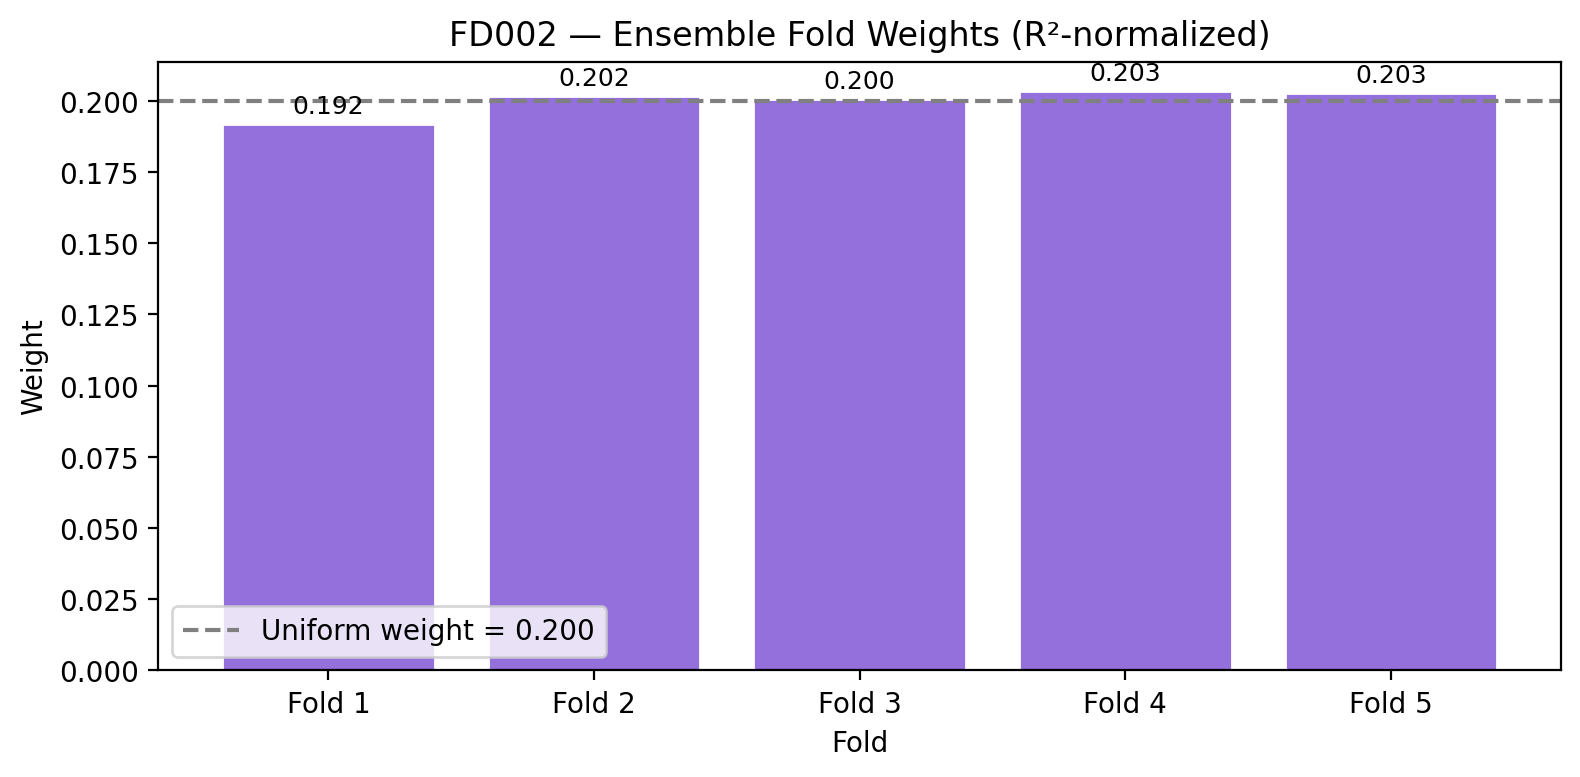

In [ ]:
# ============================================================
# ADVANCED RUL PREDICTION: Gated Ensemble BiLSTM + Attention (Optimized)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# MODIFIED create_sequences function to handle missing 'RUL' column for test set
def create_sequences(df, window_size, stride, engine_col='engine'):
    sequences, targets, engine_ids = [], [], []

    # Check if 'RUL' column exists in the DataFrame
    has_rul = 'RUL' in df.columns

    for engine_id in df[engine_col].unique():
        engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
        feature_cols = [col for col in engine_data.columns if col not in ['engine', 'cycle', 'RUL']]

        values = engine_data[feature_cols].values

        if has_rul:
            rul_values = engine_data['RUL'].values
        else:
            # If RUL column is not present (e.g., for test data), create a dummy array.
            # These 'targets' will be discarded for X_test anyway.
            rul_values = np.array([])

        # Ensure there are enough data points for the window
        if len(values) < window_size:
            continue # Skip engines that are too short for a single sequence

        for i in range(0, len(values) - window_size + 1, stride):
            sequences.append(values[i:i + window_size])
            if has_rul: # Only append RUL target if RUL column exists
                targets.append(rul_values[i + window_size - 1])
            engine_ids.append(engine_id)

    return np.array(sequences), np.array(targets), np.array(engine_ids)


CONFIG = {
    'WINDOW_SIZE': 60,
    'STRIDE': 2,
    'LSTM_UNITS': [128, 64],
    'DENSE_UNITS': 80,
    'DROPOUT_RATE': 0.3,
    'L2_REG': 0.001,
    'BATCH_SIZE': 32,
    'EPOCHS': 200,
    'LEARNING_RATE': 0.0005,
    'PATIENCE': 35,
    'N_SPLITS': 5
}

print("\nOptimized Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


X_train, y_train, train_engine_ids = create_sequences(
    df_train, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE']
)
X_test, _, test_engine_ids = create_sequences(
    df_test, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE']
)

print(f"Training sequences: {X_train.shape}")
print(f"Test sequences: {X_test.shape}")


# ============================================================
# Custom Layers
# ============================================================

class GatingLayer(layers.Layer):
    def __init__(self, num_branches, **kwargs):
        super(GatingLayer, self).__init__(**kwargs)
        self.num_branches = num_branches

    def build(self, input_shape):
        self.gate_weights = self.add_weight(
            shape=(input_shape[0][-1], self.num_branches),
            initializer='glorot_uniform',
            trainable=True
        )
        self.gate_bias = self.add_weight(
            shape=(self.num_branches,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        input_stats = tf.reduce_mean(inputs[0], axis=1)
        gate_scores = tf.nn.softmax(tf.matmul(input_stats, self.gate_weights) + self.gate_bias, axis=-1)
        gate_scores = tf.expand_dims(tf.expand_dims(gate_scores, 1), -1)
        stacked = tf.stack(inputs, axis=2)
        gated = stacked * gate_scores
        fused = tf.reduce_sum(gated, axis=2)
        return fused


class AttentionLayer(layers.Layer):
    """Attention mechanism to highlight critical timesteps after fusion."""
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],),
                                 initializer="glorot_uniform", trainable=True)

    def call(self, x):
        u_t = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attn_scores = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        attn_scores = tf.expand_dims(attn_scores, -1)
        context = tf.reduce_sum(x * attn_scores, axis=1)
        return context


# ============================================================
# Optimized Gated BiLSTM + Attention Model
# ============================================================

def build_gated_attention_bilstm(input_shape, config):
    inputs = layers.Input(shape=input_shape, name='input')

    # Parallel branches: LSTM, GRU, CNN
    branch_lstm = layers.LSTM(64, return_sequences=True,
                              kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_lstm = layers.LayerNormalization()(branch_lstm)

    branch_gru = layers.GRU(64, return_sequences=True,
                            kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_gru = layers.LayerNormalization()(branch_gru)

    branch_cnn = layers.Conv1D(64, 5, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_cnn = layers.Conv1D(64, 3, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(config['L2_REG']))(branch_cnn)
    branch_cnn = layers.LayerNormalization()(branch_cnn)

    fused = GatingLayer(num_branches=3)([branch_lstm, branch_gru, branch_cnn])
    fused = layers.Dropout(config['DROPOUT_RATE'])(fused)

    # BiLSTM layers for sequential modeling
    x = layers.Bidirectional(
        layers.LSTM(config['LSTM_UNITS'][0],
                    return_sequences=True,
                    kernel_regularizer=regularizers.l2(config['L2_REG'])),
        name='bilstm_1'
    )(fused)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    x = layers.Bidirectional(
        layers.LSTM(config['LSTM_UNITS'][1],
                    return_sequences=True,
                    kernel_regularizer=regularizers.l2(config['L2_REG'])),
        name='bilstm_2'
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    # Attention layer
    context = AttentionLayer()(x)

    # Dense head
    x = layers.Dense(config['DENSE_UNITS'], activation='relu')(context)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    outputs = layers.Dense(1, activation='linear', name='rul_output')(x)

    model = models.Model(inputs, outputs, name='Gated_Attention_BiLSTM')

    opt = optimizers.Adam(learning_rate=config['LEARNING_RATE'])
    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae', 'mse']
    )
    return model


# ============================================================
# Train with Advanced Callbacks
# ============================================================

def train_model_with_cv(X_train, y_train, engine_ids, input_shape, config, n_splits=5):
    from sklearn.model_selection import GroupKFold

    gkf = GroupKFold(n_splits=n_splits)
    results, models_list = [], []

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, engine_ids), 1):
        print(f"\n{'='*25} FOLD {fold}/{n_splits} {'='*25}")
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = build_gated_attention_bilstm(input_shape, config)

        cb = [
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=6, min_lr=5e-6),
            callbacks.EarlyStopping(monitor='val_loss', patience=config['PATIENCE'],
                                    restore_best_weights=True),
            callbacks.ModelCheckpoint(f"best_fold_{fold}.h5", save_best_only=True)
        ]

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=config['EPOCHS'],
            batch_size=config['BATCH_SIZE'],
            verbose=1,
            callbacks=cb
        )

        val_loss, val_mae, val_mse = model.evaluate(X_val, y_val, verbose=0)
        val_rmse = np.sqrt(val_mse)

        y_pred = model.predict(X_val, verbose=0).flatten()
        val_r2 = r2_score(y_val, y_pred)

        results.append({'fold': fold, 'mae': val_mae, 'rmse': val_rmse, 'r2': val_r2})
        models_list.append(model)

        print(f"Fold {fold} Results -> MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")

    print("\n=== Cross-Validation Summary ===")
    avg_mae = np.mean([r['mae'] for r in results])
    avg_rmse = np.mean([r['rmse'] for r in results])
    avg_r2 = np.mean([r['r2'] for r in results])
    print(f"MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}, R²: {avg_r2:.4f}")

    best_model_idx = np.argmax([r['r2'] for r in results])
    print(f"\nBest Fold: {best_model_idx + 1}")
    return models_list, results


# ============================================================
# Execute Training
# ============================================================

input_shape = (X_train.shape[1], X_train.shape[2])
all_models, cv_results = train_model_with_cv(
    X_train, y_train, train_engine_ids, input_shape, CONFIG, CONFIG['N_SPLITS']
)

# ============================================================
# Weighted Ensemble by fold R² score
# ============================================================

fold_r2_scores = np.array([r['r2'] for r in cv_results])
fold_weights = fold_r2_scores / fold_r2_scores.sum()  # normalize to sum=1

print("\nFold weights:")
for i, (r2, w) in enumerate(zip(fold_r2_scores, fold_weights), 1):
    print(f"  Fold {i}: R²={r2:.4f}, weight={w:.4f}")

all_preds = []
for m in all_models:
    preds = m.predict(X_test, verbose=0).flatten()
    preds = np.clip(preds, 0, None)
    all_preds.append(preds)

# Weighted average across all fold models
y_test_pred_all = np.average(all_preds, axis=0, weights=fold_weights)

# ============================================================
# Evaluate on Test Set
# ============================================================

# Take last window per engine
unique_engines = sorted(set(test_engine_ids))
y_true, y_pred = [], []
for eng_id in unique_engines:
    mask = test_engine_ids == eng_id
    y_pred.append(y_test_pred_all[mask][-1])
    y_true.append(df_test_RUL.iloc[int(eng_id) - 1]['RUL'])

y_true, y_pred = np.array(y_true), np.array(y_pred)
test_mae  = mean_absolute_error(y_true, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
test_r2   = r2_score(y_true, y_pred)

print(f"\n✅ Weighted Ensemble Test Results:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

if test_r2 >= 0.85:
    print("\n🏆 EXCELLENT PERFORMANCE ACHIEVED!")



import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Prep: define y_pred_final and supporting variables
# ============================================================

y_pred_final = y_pred  # weighted ensemble predictions (from evaluation step)
final_r2     = test_r2
sorted_idx   = np.argsort(y_true)

# Single best model predictions (for comparison plot)
best_fold_idx   = np.argmax(fold_r2_scores)
y_pred_single   = np.clip(all_models[best_fold_idx].predict(X_test, verbose=0).flatten(), 0, None)

# Per-engine last-window for single model
y_pred_single_eng = []
for eng_id in unique_engines:
    mask = test_engine_ids == eng_id
    y_pred_single_eng.append(y_pred_single[mask][-1])
y_pred_single_eng = np.array(y_pred_single_eng)

y_pred_ens = y_pred_final  # alias for clarity in plot 5

# ============================================================
# Plot 1 — True vs Predicted sorted by True RUL
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(y_true[sorted_idx],       label='True RUL',
         marker='o', ms=3, color='steelblue')
plt.plot(y_pred_final[sorted_idx], label='Predicted RUL',
         marker='x', ms=3, color='tomato')
plt.xlabel('Engine (sorted by True RUL)')
plt.ylabel('RUL')
plt.title('FD002 — True vs Predicted RUL (Weighted Ensemble, sorted by True RUL)')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2 — Scatter: Predicted vs True
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred_final, alpha=0.5, s=15, color='steelblue')
mn = min(y_true.min(), y_pred_final.min())
mx = max(y_true.max(), y_pred_final.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title(f'FD002 — Predicted vs True RUL  (R²={final_r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3 — Residual Distribution
# ============================================================

residuals = y_pred_final - y_true
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Zero bias')
plt.axvline(residuals.mean(), color='orange', linestyle='--',
            label=f'Mean bias: {residuals.mean():+.2f}')
plt.xlabel('Prediction Error (pred − true)')
plt.ylabel('Count')
plt.title('FD002 — Residual Distribution')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4 — CV Fold Performance
# ============================================================

fold_labels = [f"Fold {r['fold']}" for r in cv_results]
fold_maes   = [r['mae'] for r in cv_results]
fold_r2s    = [r['r2']  for r in cv_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(fold_labels, fold_maes, color='steelblue')
axes[0].set_title('FD002 — Validation MAE per Fold')
axes[0].set_ylabel('MAE')

axes[1].bar(fold_labels, fold_r2s, color='tomato')
axes[1].set_title('FD002 — Validation R² per Fold')
axes[1].set_ylabel('R²')
axes[1].axhline(0.80, color='green', linestyle='--', label='Target R²=0.80')
axes[1].legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5 — Single Best Fold vs Weighted Ensemble vs True RUL
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(y_true[sorted_idx],                  label='True RUL',
         color='steelblue', lw=1.5)
plt.plot(y_pred_single_eng[sorted_idx],        label=f'Best Fold (Fold {best_fold_idx+1})',
         color='orange', lw=1, alpha=0.7)
plt.plot(y_pred_ens[sorted_idx],               label='Weighted Ensemble',
         color='tomato', lw=1.5)
plt.xlabel('Engine (sorted by True RUL)')
plt.ylabel('RUL')
plt.title('FD002 — Best Single Fold vs Weighted Ensemble vs True RUL')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 6 — Fold Weights (FD002 specific — shows ensemble contribution)
# ============================================================

plt.figure(figsize=(8, 4))
bars = plt.bar(fold_labels, fold_weights, color='mediumpurple', edgecolor='white')
plt.axhline(1 / len(fold_weights), color='gray', linestyle='--',
            label=f'Uniform weight = {1/len(fold_weights):.3f}')
for bar, w in zip(bars, fold_weights):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{w:.3f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Fold')
plt.ylabel('Weight')
plt.title('FD002 — Ensemble Fold Weights (R²-normalized)')
plt.legend()
plt.tight_layout()
plt.show()